<a href="https://colab.research.google.com/github/agaba123/masters_project/blob/main/Planting_time_Advisory(FINAL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# MEMORY-SAFE ERA5 CLIMATE PIPELINE
# Western Uganda | Year-by-year | Thesis-ready baseline model
# ============================================================

import os
import gc
import json
import joblib
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------
# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')
xr.set_options(use_new_combine_kwarg_defaults=True)

BASE_PATH = "/content/drive/MyDrive/regional_weather_data"

OUTPUT_CSV = "/content/drive/MyDrive/weekly_climate_full.csv"
MODEL_PATH = "/content/drive/MyDrive/climate_season_model.pkl"
SCALER_PATH = "/content/drive/MyDrive/climate_scaler.pkl"
FEATURES_PATH = "/content/drive/MyDrive/climate_features.json"

LAT_MIN, LAT_MAX = -1.5, 1.5
LON_MIN, LON_MAX = 29.5, 31.5

# ------------------------------------------------------------
# STEP 1: IDENTIFY VALID YEARS
# ------------------------------------------------------------

files = os.listdir(BASE_PATH)

years = sorted(
    set(
        f.split("_")[0]
        for f in files
        if f.endswith(".nc") and ("accum" in f or "instant" in f)
    )
)

print("Years found:", years[:5], "...", years[-5:])
print("Total candidate years:", len(years))

# ------------------------------------------------------------
# STEP 2: PROCESS EACH YEAR SAFELY
# ------------------------------------------------------------

all_years = []

for year in years:
    print(f"\nProcessing year: {year}")

    rain_file = os.path.join(BASE_PATH, f"{year}_accum.nc")
    temp_file = os.path.join(BASE_PATH, f"{year}_instant.nc")

    if not os.path.exists(rain_file) or not os.path.exists(temp_file):
        print(f"Skipping {year}: missing accum or instant file.")
        continue

    try:
        rain_ds = xr.open_dataset(rain_file)
        temp_ds = xr.open_dataset(temp_file)

        ds = xr.merge([rain_ds, temp_ds], compat="override")

        # Standardize time coordinate
        if "valid_time" in ds.coords:
            ds = ds.rename({"valid_time": "time"})
        elif "valid_time" in ds.variables:
            ds = ds.rename({"valid_time": "time"})

        if "time" not in ds.coords:
            raise ValueError(f"No usable time coordinate found for year {year}")

        ds["time"] = pd.to_datetime(ds["time"].values)

        # Keep only required variables
        ds = ds[["tp", "t2m"]]

        # Spatial clipping
        ds = ds.sel(
            latitude=slice(LAT_MAX, LAT_MIN),
            longitude=slice(LON_MIN, LON_MAX)
        )

        # Unit conversion
        ds["tp"] = ds["tp"] * 1000       # metres to mm
        ds["t2m"] = ds["t2m"] - 273.15   # Kelvin to Celsius

        # Weekly aggregation
        weekly = xr.Dataset({
            "tp": ds["tp"].resample(time="1W").sum(),
            "t2m": ds["t2m"].resample(time="1W").mean()
        })

        df_year = weekly.to_dataframe().reset_index()
        df_year = df_year.dropna()

        # Remove impossible values
        df_year = df_year[df_year["tp"] >= 0]
        df_year = df_year[(df_year["t2m"] > 0) & (df_year["t2m"] < 45)]

        all_years.append(df_year)

        print(f"{year} processed successfully. Rows: {df_year.shape[0]}")

    except Exception as e:
        print(f"Error processing {year}: {e}")

    finally:
        # Free memory
        for obj in ["rain_ds", "temp_ds", "ds", "weekly", "df_year"]:
            if obj in locals():
                del locals()[obj]
        gc.collect()

# ------------------------------------------------------------
# STEP 3: COMBINE ALL YEARS
# ------------------------------------------------------------

if len(all_years) == 0:
    raise RuntimeError("No yearly data was processed. Check file names and folder path.")

full_df = pd.concat(all_years, ignore_index=True)
full_df["time"] = pd.to_datetime(full_df["time"])

print("\nCombined dataset shape:", full_df.shape)

# ------------------------------------------------------------
# STEP 4: SORT AND FEATURE ENGINEERING
# ------------------------------------------------------------

full_df = full_df.sort_values(["latitude", "longitude", "time"]).reset_index(drop=True)

full_df["year"] = full_df["time"].dt.year
full_df["week_of_year"] = full_df["time"].dt.isocalendar().week.astype(int)

group_cols = ["latitude", "longitude"]

# Lag features
full_df["rain_lag1"] = full_df.groupby(group_cols)["tp"].shift(1)
full_df["rain_lag2"] = full_df.groupby(group_cols)["tp"].shift(2)
full_df["temp_lag1"] = full_df.groupby(group_cols)["t2m"].shift(1)

# Rolling rainfall features
full_df["rain_roll3_mean"] = (
    full_df.groupby(group_cols)["tp"]
    .rolling(3)
    .mean()
    .reset_index(level=[0, 1], drop=True)
)

full_df["rain_roll4_sum"] = (
    full_df.groupby(group_cols)["tp"]
    .rolling(4)
    .sum()
    .reset_index(level=[0, 1], drop=True)
)

# Rainfall dynamics
full_df["rain_trend"] = full_df["rain_lag1"] - full_df["rain_lag2"]
full_df["rain_acceleration"] = full_df["tp"] - 2 * full_df["rain_lag1"] + full_df["rain_lag2"]

# Cyclical week encoding
full_df["sin_week"] = np.sin(2 * np.pi * full_df["week_of_year"] / 52)
full_df["cos_week"] = np.cos(2 * np.pi * full_df["week_of_year"] / 52)

# Drop rows created by lag/rolling operations
full_df = full_df.dropna().reset_index(drop=True)

print("Dataset after feature engineering:", full_df.shape)

# ------------------------------------------------------------
# STEP 5: CREATE MEANINGFUL SEASON LABELS
# ------------------------------------------------------------
# KMeans cluster labels are arbitrary, so we remap them:
# 0 = Dry, 1 = Transition, 2 = Rainy

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
full_df["season_raw"] = kmeans.fit_predict(full_df[["tp", "rain_roll3_mean", "rain_roll4_sum"]])

cluster_means = full_df.groupby("season_raw")["tp"].mean().sort_values()

label_map = {
    cluster_means.index[0]: 0,  # lowest rainfall = Dry
    cluster_means.index[1]: 1,  # middle rainfall = Transition
    cluster_means.index[2]: 2   # highest rainfall = Rainy
}

full_df["season"] = full_df["season_raw"].map(label_map)

print("\nSeason distribution:")
print(full_df["season"].value_counts().sort_index())

print("\nMean rainfall by season:")
print(full_df.groupby("season")["tp"].mean())

# ------------------------------------------------------------
# STEP 6: CREATE TARGET VARIABLE
# ------------------------------------------------------------
# Predict next week's seasonal state

full_df["season_next"] = full_df.groupby(group_cols)["season"].shift(-1)
full_df = full_df.dropna().reset_index(drop=True)

full_df["season_next"] = full_df["season_next"].astype(int)

# ------------------------------------------------------------
# STEP 7: TRAIN / TEST SPLIT
# ------------------------------------------------------------
# Time-based split is more scientific than random split.

split_year = 2016

train = full_df[full_df["year"] < split_year]
test = full_df[full_df["year"] >= split_year]

features = [
    "tp",
    "t2m",
    "rain_lag1",
    "rain_lag2",
    "temp_lag1",
    "rain_roll3_mean",
    "rain_roll4_sum",
    "rain_trend",
    "rain_acceleration",
    "sin_week",
    "cos_week"
]

X_train = train[features]
y_train = train["season_next"]

X_test = test[features]
y_test = test["season_next"]

# ------------------------------------------------------------
# STEP 8: SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# STEP 9: MODEL TRAINING
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# STEP 10: EVALUATION
# ------------------------------------------------------------

preds = model.predict(X_test_scaled)

print("\nModel Accuracy:", accuracy_score(y_test, preds))

print("\nClassification Report:")
print(classification_report(
    y_test,
    preds,
    target_names=["Dry", "Transition", "Rainy"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

# ------------------------------------------------------------
# STEP 11: SAVE OUTPUTS
# ------------------------------------------------------------

full_df.to_csv(OUTPUT_CSV, index=False)
joblib.dump(model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

with open(FEATURES_PATH, "w") as f:
    json.dump(features, f)

print("\nSaved outputs:")
print("Dataset:", OUTPUT_CSV)
print("Model:", MODEL_PATH)
print("Scaler:", SCALER_PATH)
print("Features:", FEATURES_PATH)

# ============================================================
# END OF PIPELINE
# ============================================================

Mounted at /content/drive
Years found: ['1980', '1981', '1982', '1983', '1984'] ... ['2021', '2022', '2023', '2024', '2025']
Total candidate years: 46

Processing year: 1980
1980 processed successfully. Rows: 6318

Processing year: 1981
1981 processed successfully. Rows: 6201

Processing year: 1982
1982 processed successfully. Rows: 6201

Processing year: 1983
1983 processed successfully. Rows: 6201

Processing year: 1984
1984 processed successfully. Rows: 6201

Processing year: 1985
1985 processed successfully. Rows: 6201

Processing year: 1986
1986 processed successfully. Rows: 6201

Processing year: 1987
1987 processed successfully. Rows: 6201

Processing year: 1988
1988 processed successfully. Rows: 6201

Processing year: 1989
1989 processed successfully. Rows: 6201

Processing year: 1990
1990 processed successfully. Rows: 6201

Processing year: 1991
1991 processed successfully. Rows: 6201

Processing year: 1992
1992 processed successfully. Rows: 6201

Processing year: 1993
1993 pr

visualizations


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (285012, 20)


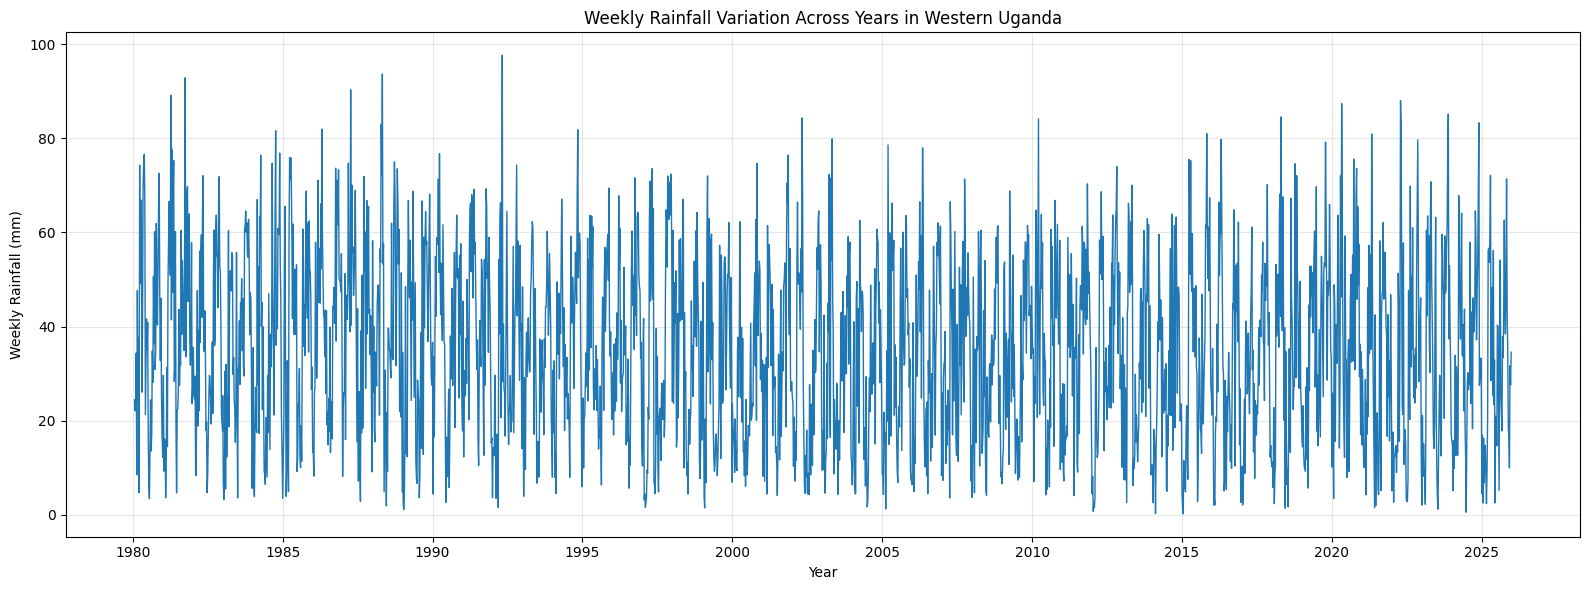

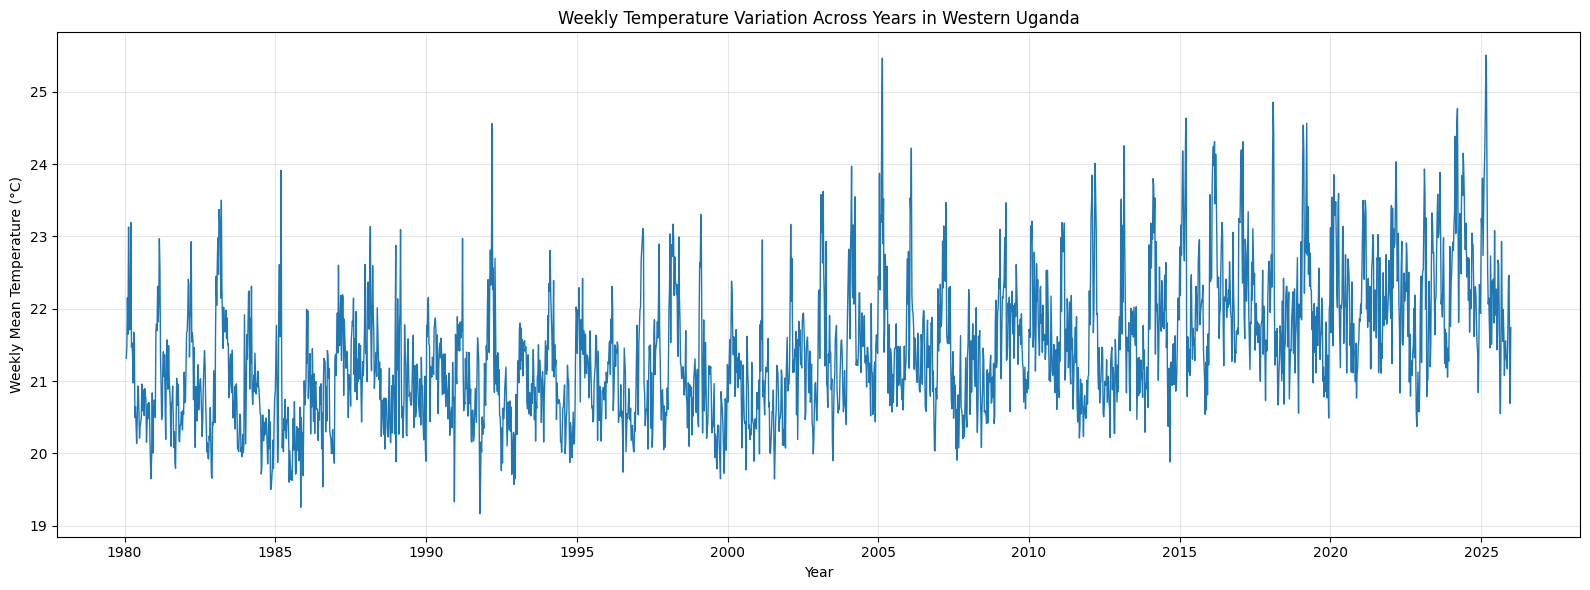

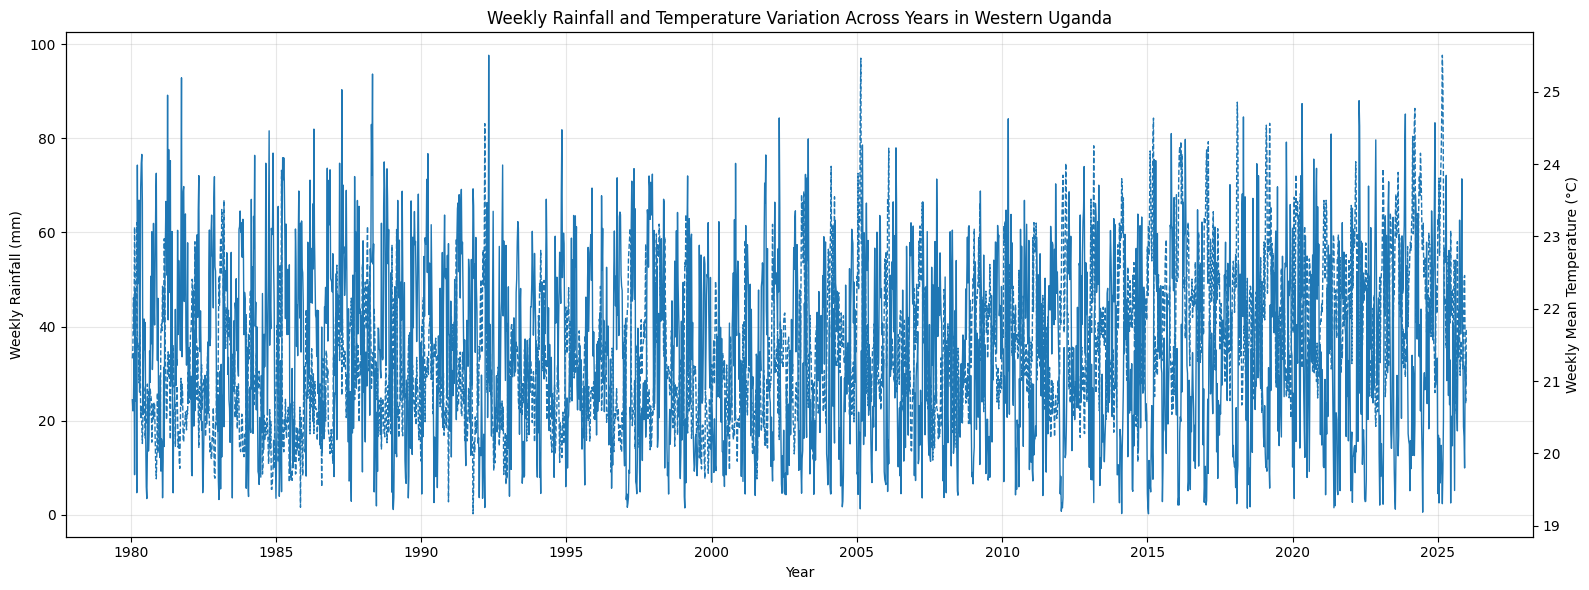

Graphs saved successfully:
Rainfall graph: /content/drive/MyDrive/weekly_rainfall_variation.png
Temperature graph: /content/drive/MyDrive/weekly_temperature_variation.png
Combined graph: /content/drive/MyDrive/weekly_rainfall_temperature_variation.png


In [ ]:
# ============================================================
# SAVE LINE GRAPHS AS PNG:
# Weekly Rainfall and Temperature Variation Across Years
# ERA5 Weekly Climate Dataset | Western Uganda
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# ------------------------------------------------------------
# STEP 1: MOUNT GOOGLE DRIVE
# ------------------------------------------------------------
drive.mount('/content/drive')

# ------------------------------------------------------------
# STEP 2: LOAD DATASET
# ------------------------------------------------------------
DATA_PATH = "/content/drive/MyDrive/weekly_climate_full.csv"

df = pd.read_csv(DATA_PATH)
df["time"] = pd.to_datetime(df["time"])

print("Dataset loaded:", df.shape)

# ------------------------------------------------------------
# STEP 3: CREATE YEAR AND WEEK COLUMNS
# ------------------------------------------------------------
df["year"] = df["time"].dt.year
df["week_of_year"] = df["time"].dt.isocalendar().week.astype(int)

# ------------------------------------------------------------
# STEP 4: AGGREGATE BY YEAR AND WEEK
# ------------------------------------------------------------
weekly_summary = (
    df.groupby(["year", "week_of_year"])
    .agg({
        "tp": "mean",
        "t2m": "mean"
    })
    .reset_index()
)

weekly_summary["date"] = pd.to_datetime(
    weekly_summary["year"].astype(str) + "-01-01"
) + pd.to_timedelta((weekly_summary["week_of_year"] - 1) * 7, unit="D")

# ------------------------------------------------------------
# OUTPUT PATHS
# ------------------------------------------------------------
rainfall_png = "/content/drive/MyDrive/weekly_rainfall_variation.png"
temperature_png = "/content/drive/MyDrive/weekly_temperature_variation.png"
combined_png = "/content/drive/MyDrive/weekly_rainfall_temperature_variation.png"

# ------------------------------------------------------------
# GRAPH 1: WEEKLY RAINFALL VARIATION
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(weekly_summary["date"], weekly_summary["tp"], linewidth=1)

plt.title("Weekly Rainfall Variation Across Years in Western Uganda")
plt.xlabel("Year")
plt.ylabel("Weekly Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(rainfall_png, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# GRAPH 2: WEEKLY TEMPERATURE VARIATION
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(weekly_summary["date"], weekly_summary["t2m"], linewidth=1)

plt.title("Weekly Temperature Variation Across Years in Western Uganda")
plt.xlabel("Year")
plt.ylabel("Weekly Mean Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(temperature_png, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# GRAPH 3: COMBINED RAINFALL AND TEMPERATURE VARIATION
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(weekly_summary["date"], weekly_summary["tp"], linewidth=1)
ax1.set_xlabel("Year")
ax1.set_ylabel("Weekly Rainfall (mm)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(weekly_summary["date"], weekly_summary["t2m"], linewidth=1, linestyle="--")
ax2.set_ylabel("Weekly Mean Temperature (°C)")

plt.title("Weekly Rainfall and Temperature Variation Across Years in Western Uganda")
fig.tight_layout()

plt.savefig(combined_png, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# PRINT SAVED FILE LOCATIONS
# ------------------------------------------------------------
print("Graphs saved successfully:")
print("Rainfall graph:", rainfall_png)
print("Temperature graph:", temperature_png)
print("Combined graph:", combined_png)

model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (285012, 20)
Columns available:
['latitude', 'longitude', 'time', 'number', 'tp', 't2m', 'year', 'week_of_year', 'rain_lag1', 'rain_lag2', 'temp_lag1', 'rain_roll3_mean', 'rain_roll4_sum', 'rain_trend', 'rain_acceleration', 'sin_week', 'cos_week', 'season_raw', 'season', 'season_next']

Current-week planting class distribution:
planting_class
0    114075
1     31777
2    139160
Name: count, dtype: int64

Next-week planting class distribution:
planting_class_next
0    113982
1     31776
2    139137
Name: count, dtype: int64

Training set: (223002, 8)
Testing set: (61893, 8)

Training target distribution:
planting_class_next
0     86312
1     24817
2    111873
Name: count, dtype: int64

Testing target distribution:
planting_class_next
0    27670
1     6959
2    27264
Name: count, dtype: int64

Training Logistic Regression

Logistic Regression Ac

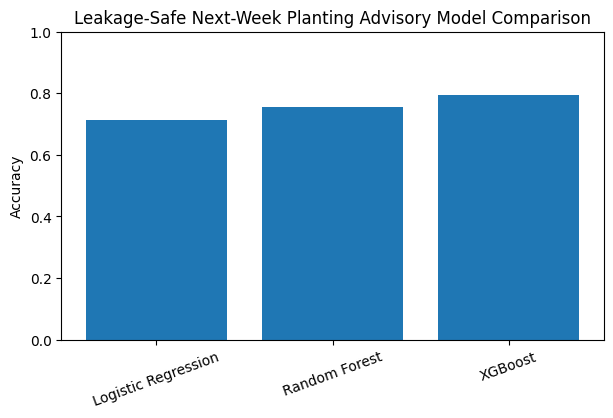

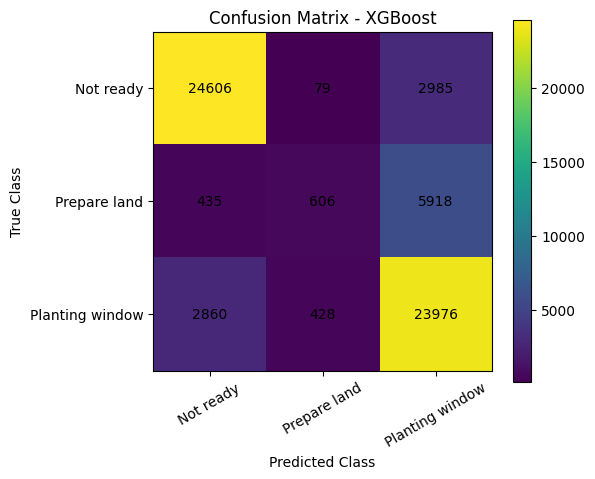

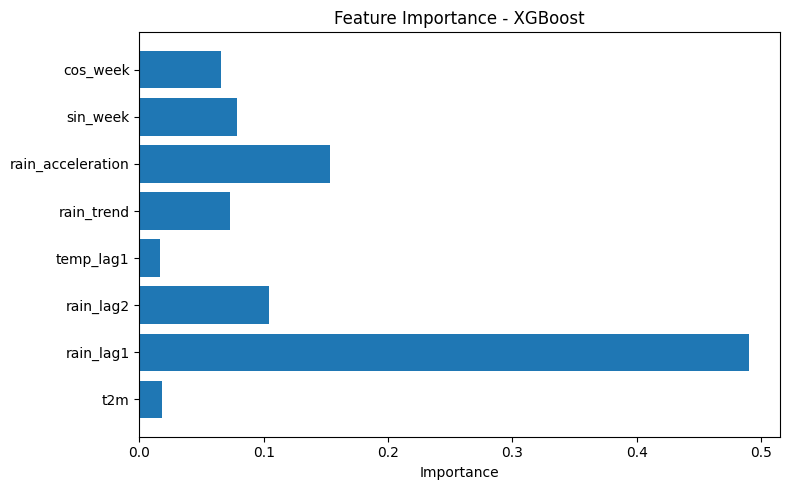


SAVED OUTPUTS
Best model: /content/drive/MyDrive/planting_advisory_model_leakage_safe.pkl
All models: /content/drive/MyDrive/planting_models_all_leakage_safe.pkl
Scaler: /content/drive/MyDrive/planting_advisory_scaler_leakage_safe.pkl
Features: /content/drive/MyDrive/planting_advisory_features_leakage_safe.json
Dataset: /content/drive/MyDrive/planting_advisory_dataset_leakage_safe.csv
Results: /content/drive/MyDrive/planting_model_results_leakage_safe.json


In [ ]:
# ============================================================
# PART 2: LEAKAGE-SAFE PLANTING-ONSET ADVISORY MODEL
# Predicts NEXT-WEEK planting readiness from current/past signals
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

# ------------------------------------------------------------
# STEP 1: LOAD BASELINE DATASET
# ------------------------------------------------------------

# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/weekly_climate_full.csv"

df = pd.read_csv(DATA_PATH)
df["time"] = pd.to_datetime(df["time"])

print("Dataset loaded:", df.shape)
print("Columns available:")
print(df.columns.tolist())

# ------------------------------------------------------------
# STEP 2: BASIC SAFETY CHECKS
# ------------------------------------------------------------

required_cols = [
    "latitude", "longitude", "time", "year",
    "tp", "t2m",
    "rain_lag1", "rain_lag2", "temp_lag1",
    "rain_roll3_mean", "rain_roll4_sum",
    "rain_trend", "rain_acceleration",
    "sin_week", "cos_week"
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.sort_values(["latitude", "longitude", "time"]).reset_index(drop=True)

# ------------------------------------------------------------
# STEP 3: CREATE CURRENT-WEEK PLANTING READINESS LABEL
# ------------------------------------------------------------
# This rule is used ONLY to define the planting state.
# It should NOT be predicted using the exact same direct features
# for the same week, otherwise target leakage occurs.
#
# Classes:
# 0 = Not ready
# 1 = Prepare land
# 2 = Planting window

def classify_current_planting_window(row):
    if row["rain_roll4_sum"] >= 70 and row["tp"] > 20:
        return 2   # Planting window
    elif row["rain_roll3_mean"] >= 20:
        return 1   # Prepare land
    else:
        return 0   # Not ready

df["planting_class"] = df.apply(classify_current_planting_window, axis=1)

print("\nCurrent-week planting class distribution:")
print(df["planting_class"].value_counts().sort_index())

# ------------------------------------------------------------
# STEP 4: SHIFT TARGET TO NEXT WEEK
# ------------------------------------------------------------
# This is the key leakage fix.
# The model will learn:
#
# Current/past climate features at week t  --->  planting readiness at week t+1
#
# This makes the system a forecasting model, not just a rule-repeater.

group_cols = ["latitude", "longitude"]

df["planting_class_next"] = (
    df.groupby(group_cols)["planting_class"].shift(-1)
)

df = df.dropna(subset=["planting_class_next"]).reset_index(drop=True)
df["planting_class_next"] = df["planting_class_next"].astype(int)

print("\nNext-week planting class distribution:")
print(df["planting_class_next"].value_counts().sort_index())

# ------------------------------------------------------------
# STEP 5: DEFINE LEAKAGE-SAFE FEATURES
# ------------------------------------------------------------
# We remove direct same-week rainfall variables that were used
# to define the target label:
#
# Removed:
# - tp
# - rain_roll3_mean
# - rain_roll4_sum
#
# Kept:
# - lagged rainfall
# - lagged temperature
# - rainfall dynamics
# - current temperature
# - seasonal encoding
#
# This makes the model more scientifically defensible.

features = [
    "t2m",
    "rain_lag1",
    "rain_lag2",
    "temp_lag1",
    "rain_trend",
    "rain_acceleration",
    "sin_week",
    "cos_week"
]

target = "planting_class_next"

X = df[features]
y = df[target]

# Clean numerical issues
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# ------------------------------------------------------------
# STEP 6: TIME-BASED TRAIN / TEST SPLIT
# ------------------------------------------------------------
# Data before 2016 is used for training.
# Data from 2016 onward is used for testing.
#
# This better simulates real-world forecasting than random splitting.

split_year = 2016

train = df[df["year"] < split_year].copy()
test = df[df["year"] >= split_year].copy()

X_train = train[features].replace([np.inf, -np.inf], np.nan)
X_test = test[features].replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

y_train = train[target]
y_test = test[target]

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

# ------------------------------------------------------------
# STEP 7: SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# STEP 8: DEFINE MODELS FOR COMPARISON
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=42
    )
}

# ------------------------------------------------------------
# STEP 9: TRAIN AND EVALUATE MODELS
# ------------------------------------------------------------

results = {}
reports = {}
conf_matrices = {}

class_names = ["Not ready", "Prepare land", "Planting window"]

for name, model in models.items():
    print(f"\n==================================================")
    print(f"Training {name}")
    print("==================================================")

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    report_text = classification_report(
        y_test,
        preds,
        target_names=class_names,
        digits=4
    )

    reports[name] = report_text
    conf_matrices[name] = confusion_matrix(y_test, preds)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(report_text)

    print("Confusion Matrix:")
    print(conf_matrices[name])

# ------------------------------------------------------------
# STEP 10: SELECT BEST MODEL BY ACCURACY
# ------------------------------------------------------------

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\n==================================================")
print("MODEL COMPARISON SUMMARY")
print("==================================================")

for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

print("\nBest model:", best_model_name)
print("Best accuracy:", results[best_model_name])

# ------------------------------------------------------------
# STEP 11: PLOT MODEL COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Leakage-Safe Next-Week Planting Advisory Model Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

# ------------------------------------------------------------
# STEP 12: PLOT CONFUSION MATRIX FOR BEST MODEL
# ------------------------------------------------------------

best_cm = conf_matrices[best_model_name]

plt.figure(figsize=(6, 5))
plt.imshow(best_cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(ticks=[0, 1, 2], labels=class_names, rotation=30)
plt.yticks(ticks=[0, 1, 2], labels=class_names)

for i in range(best_cm.shape[0]):
    for j in range(best_cm.shape[1]):
        plt.text(j, i, best_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 13: FEATURE IMPORTANCE / COEFFICIENT INSPECTION
# ------------------------------------------------------------

if hasattr(best_model, "feature_importances_"):
    plt.figure(figsize=(8, 5))
    plt.barh(features, best_model.feature_importances_)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

elif best_model_name == "Logistic Regression":
    coef = np.mean(np.abs(best_model.coef_), axis=0)

    plt.figure(figsize=(8, 5))
    plt.barh(features, coef)
    plt.title("Average Absolute Coefficients - Logistic Regression")
    plt.xlabel("Coefficient Magnitude")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# STEP 14: SAVE MODELS AND OUTPUTS
# ------------------------------------------------------------

BEST_MODEL_PATH = "/content/drive/MyDrive/planting_advisory_model_leakage_safe.pkl"
ALL_MODELS_PATH = "/content/drive/MyDrive/planting_models_all_leakage_safe.pkl"
SCALER_PATH = "/content/drive/MyDrive/planting_advisory_scaler_leakage_safe.pkl"
FEATURES_PATH = "/content/drive/MyDrive/planting_advisory_features_leakage_safe.json"
DATASET_PATH = "/content/drive/MyDrive/planting_advisory_dataset_leakage_safe.csv"
RESULTS_PATH = "/content/drive/MyDrive/planting_model_results_leakage_safe.json"

joblib.dump(best_model, BEST_MODEL_PATH)
joblib.dump(models, ALL_MODELS_PATH)
joblib.dump(scaler, SCALER_PATH)

with open(FEATURES_PATH, "w") as f:
    json.dump(features, f)

df.to_csv(DATASET_PATH, index=False)

results_to_save = {
    "target": target,
    "features": features,
    "split_year": split_year,
    "accuracies": results,
    "best_model": best_model_name
}

with open(RESULTS_PATH, "w") as f:
    json.dump(results_to_save, f, indent=4)

print("\n==================================================")
print("SAVED OUTPUTS")
print("==================================================")
print("Best model:", BEST_MODEL_PATH)
print("All models:", ALL_MODELS_PATH)
print("Scaler:", SCALER_PATH)
print("Features:", FEATURES_PATH)
print("Dataset:", DATASET_PATH)
print("Results:", RESULTS_PATH)




updated fewshot learning


In [ ]:
# ============================================================
# PART 3: FARMER INPUT + LEAKAGE-SAFE NEXT-WEEK ADVISORY
# Works with PART 2 leakage-safe saved models
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# STEP 1: LOAD MODELS, SCALER, AND FEATURE LIST
# ------------------------------------------------------------

ALL_MODELS_PATH = "/content/drive/MyDrive/planting_models_all_leakage_safe.pkl"
BEST_MODEL_PATH = "/content/drive/MyDrive/planting_advisory_model_leakage_safe.pkl"
SCALER_PATH = "/content/drive/MyDrive/planting_advisory_scaler_leakage_safe.pkl"
FEATURES_PATH = "/content/drive/MyDrive/planting_advisory_features_leakage_safe.json"

models = joblib.load(ALL_MODELS_PATH)
best_model = joblib.load(BEST_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

with open(FEATURES_PATH, "r") as f:
    features = json.load(f)

print("Loaded models:")
for name in models.keys():
    print("-", name)

print("\nFeatures used:")
print(features)

# ------------------------------------------------------------
# STEP 2: FARMER INPUT
# ------------------------------------------------------------

def get_farmer_input():
    print("\nENTER FARM CLIMATE CONDITIONS\n")
    print("Use rainfall totals in millimetres (mm).")

    rain_2weeks_ago = float(input("Rainfall 2 weeks ago (mm): "))
    rain_last_week = float(input("Rainfall last week (mm): "))
    rain_this_week = float(input("Rainfall this week (mm): "))

    temp_now = float(input("Current average temperature this week (°C): "))
    temp_last_week = float(input("Average temperature last week (°C): "))

    week = int(input("Current week of year (1-52): "))

    if week < 1 or week > 52:
        raise ValueError("Week of year must be between 1 and 52.")

    return rain_2weeks_ago, rain_last_week, rain_this_week, temp_now, temp_last_week, week

# ------------------------------------------------------------
# STEP 3: BUILD MODEL FEATURES
# ------------------------------------------------------------
# Must match the leakage-safe feature list from PART 2:
# [
#   "t2m",
#   "rain_lag1",
#   "rain_lag2",
#   "temp_lag1",
#   "rain_trend",
#   "rain_acceleration",
#   "sin_week",
#   "cos_week"
# ]

def build_input_features(rain_2weeks_ago, rain_last_week, rain_this_week,
                         temp_now, temp_last_week, week):

    rain_trend = rain_last_week - rain_2weeks_ago
    rain_acceleration = rain_this_week - 2 * rain_last_week + rain_2weeks_ago

    input_df = pd.DataFrame([{
        "t2m": temp_now,
        "rain_lag1": rain_last_week,
        "rain_lag2": rain_2weeks_ago,
        "temp_lag1": temp_last_week,
        "rain_trend": rain_trend,
        "rain_acceleration": rain_acceleration,
        "sin_week": np.sin(2 * np.pi * week / 52),
        "cos_week": np.cos(2 * np.pi * week / 52)
    }])

    return input_df[features]

# ------------------------------------------------------------
# STEP 4: FEW-SHOT LOCAL ADAPTATION
# ------------------------------------------------------------
# This does not retrain the model.
# It lightly adjusts the prediction using a small number of recent
# farm-level observations.
#
# Since the model predicts NEXT-WEEK readiness, the few-shot adjustment
# estimates whether recent local rainfall suggests improving or worsening
# conditions for the coming week.

def few_shot_adjustment(pred_class, rain_2weeks_ago, rain_last_week, rain_this_week):
    recent_avg = np.mean([rain_2weeks_ago, rain_last_week, rain_this_week])
    latest_trend = rain_this_week - rain_last_week
    earlier_trend = rain_last_week - rain_2weeks_ago

    adjusted = int(pred_class)

    # Strong and increasing rainfall suggests better readiness next week.
    if recent_avg >= 25 and latest_trend >= 0:
        adjusted = min(2, adjusted + 1)

    # Moderate rainfall with stable trend suggests preparation.
    elif recent_avg >= 15 and earlier_trend >= 0:
        adjusted = max(adjusted, 1)

    # Very low rainfall suggests reduced readiness.
    elif recent_avg < 10:
        adjusted = max(0, adjusted - 1)

    return adjusted

# ------------------------------------------------------------
# STEP 5: INTERPRETATION
# ------------------------------------------------------------

def interpret_advice(final_class):
    if final_class == 2:
        recommendation = "PLANT NEXT WEEK"
        reason = (
            "The model predicts that rainfall conditions are likely to support "
            "a planting window in the coming week."
        )

    elif final_class == 1:
        recommendation = "PREPARE LAND"
        reason = (
            "The model predicts improving or transitional rainfall conditions. "
            "Land preparation is advised while monitoring rainfall before planting."
        )

    else:
        recommendation = "WAIT"
        reason = (
            "The model predicts that rainfall conditions may not yet be sufficient "
            "for reliable planting next week."
        )

    return recommendation, reason

# ------------------------------------------------------------
# STEP 6: RUN A SINGLE MODEL
# ------------------------------------------------------------

def run_model(model_name, model, input_scaled,
              rain_2weeks_ago, rain_last_week, rain_this_week):

    raw_pred = int(model.predict(input_scaled)[0])

    final_pred = few_shot_adjustment(
        raw_pred,
        rain_2weeks_ago,
        rain_last_week,
        rain_this_week
    )

    recommendation, reason = interpret_advice(final_pred)

    print("\n==============================")
    print(f"MODEL: {model_name}")
    print("==============================")

    print(f"Raw model prediction class: {raw_pred}")
    print(f"Few-shot adjusted class: {final_pred}")

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(input_scaled)[0]

        # Some models may not include all classes if training data had issues.
        print("\nPrediction probabilities:")
        class_labels = ["Not ready", "Prepare land", "Planting window"]

        for i, prob in enumerate(probs):
            print(f"{class_labels[i]}: {prob:.2f}")

    print(f"\nRecommendation: {recommendation}")
    print(f"Reason: {reason}")

# ------------------------------------------------------------
# STEP 7: CONSENSUS ADVISORY FROM ALL MODELS
# ------------------------------------------------------------

def consensus_advisory(input_scaled, r2, r1, r0):
    adjusted_predictions = []

    print("\n==============================")
    print("ALL MODEL RECOMMENDATIONS")
    print("==============================")

    for name, model in models.items():
        raw_pred = int(model.predict(input_scaled)[0])
        final_pred = few_shot_adjustment(raw_pred, r2, r1, r0)
        adjusted_predictions.append(final_pred)

        recommendation, reason = interpret_advice(final_pred)

        print(f"\n{name}")
        print(f"Raw prediction: {raw_pred}")
        print(f"Few-shot adjusted prediction: {final_pred}")
        print(f"Recommendation: {recommendation}")

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(input_scaled)[0]
            print(
                f"Probabilities -> Not ready: {probs[0]:.2f}, "
                f"Prepare land: {probs[1]:.2f}, "
                f"Planting window: {probs[2]:.2f}"
            )

    # Majority vote
    counts = {
        0: adjusted_predictions.count(0),
        1: adjusted_predictions.count(1),
        2: adjusted_predictions.count(2)
    }

    consensus_class = max(counts, key=counts.get)
    recommendation, reason = interpret_advice(consensus_class)

    print("\n==============================")
    print("CONSENSUS ADVISORY")
    print("==============================")
    print("Model votes:", counts)
    print("Final recommendation:", recommendation)
    print("Reason:", reason)

# ------------------------------------------------------------
# STEP 8: MAIN ADVISORY SYSTEM
# ------------------------------------------------------------

def recommend_planting():

    r2, r1, r0, temp_now, temp_last, week = get_farmer_input()

    input_df = build_input_features(
        r2, r1, r0,
        temp_now, temp_last,
        week
    )

    print("\nGenerated model input:")
    print(input_df)

    input_scaled = scaler.transform(input_df)

    print("\nChoose model:")
    print("1. Logistic Regression")
    print("2. Random Forest")
    print("3. XGBoost")
    print("4. Show recommendations from all models")
    print("5. Use best saved model only")

    choice = input("\nEnter choice (1/2/3/4/5): ")

    if choice == "1":
        run_model(
            "Logistic Regression",
            models["Logistic Regression"],
            input_scaled,
            r2, r1, r0
        )

    elif choice == "2":
        run_model(
            "Random Forest",
            models["Random Forest"],
            input_scaled,
            r2, r1, r0
        )

    elif choice == "3":
        run_model(
            "XGBoost",
            models["XGBoost"],
            input_scaled,
            r2, r1, r0
        )

    elif choice == "4":
        consensus_advisory(input_scaled, r2, r1, r0)

    elif choice == "5":
        # Try to identify best model name from dictionary
        best_name = None
        for name, mdl in models.items():
            if type(mdl).__name__ == type(best_model).__name__:
                best_name = name
                break

        if best_name is None:
            best_name = "Best Saved Model"

        run_model(
            best_name,
            best_model,
            input_scaled,
            r2, r1, r0
        )

    else:
        print("Invalid choice. Showing all models by default.")
        consensus_advisory(input_scaled, r2, r1, r0)

    print("\nSystem basis:")
    print("- Historical ERA5 climate data")
    print("- Leakage-safe next-week planting readiness model")
    print("- Current and past rainfall/temperature inputs")
    print("- Few-shot local adaptation from farmer-provided observations")

# ------------------------------------------------------------
# STEP 9: RUN SYSTEM
# ------------------------------------------------------------

recommend_planting()

Loaded models:
- Logistic Regression
- Random Forest
- XGBoost

Features used:
['t2m', 'rain_lag1', 'rain_lag2', 'temp_lag1', 'rain_trend', 'rain_acceleration', 'sin_week', 'cos_week']

ENTER FARM CLIMATE CONDITIONS

Use rainfall totals in millimetres (mm).
Rainfall 2 weeks ago (mm): 42.1
Rainfall last week (mm): 48.5
Rainfall this week (mm): 45.2
Current average temperature this week (°C): 23
Average temperature last week (°C): 22
Current week of year (1-52): 18

Generated model input:
    t2m  rain_lag1  rain_lag2  temp_lag1  rain_trend  rain_acceleration  \
0  23.0       48.5       42.1       22.0         6.4               -9.7   

   sin_week  cos_week  
0  0.822984 -0.568065  

Choose model:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. Show recommendations from all models
5. Use best saved model only

Enter choice (1/2/3/4/5): 4

ALL MODEL RECOMMENDATIONS

Logistic Regression
Raw prediction: 2
Few-shot adjusted prediction: 2
Recommendation: PLANT NEXT WEEK
Probabilities -

better adaption


In [ ]:
# ============================================================
# PART 3: FARMER INPUT + STRONG FEW-SHOT LOCAL ADAPTATION
# Uses similar historical climate episodes for local adaptation
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import euclidean_distances

# ------------------------------------------------------------
# STEP 1: LOAD MODELS, SCALER, FEATURES, AND HISTORICAL DATASET
# ------------------------------------------------------------
# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')
ALL_MODELS_PATH = "/content/drive/MyDrive/planting_models_all_leakage_safe.pkl"
BEST_MODEL_PATH = "/content/drive/MyDrive/planting_advisory_model_leakage_safe.pkl"
SCALER_PATH = "/content/drive/MyDrive/planting_advisory_scaler_leakage_safe.pkl"
FEATURES_PATH = "/content/drive/MyDrive/planting_advisory_features_leakage_safe.json"
DATASET_PATH = "/content/drive/MyDrive/planting_advisory_dataset_leakage_safe.csv"

models = joblib.load(ALL_MODELS_PATH)
best_model = joblib.load(BEST_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

with open(FEATURES_PATH, "r") as f:
    features = json.load(f)

historical_df = pd.read_csv(DATASET_PATH)
historical_df["time"] = pd.to_datetime(historical_df["time"])

target_col = "planting_class_next"

print("Loaded models:")
for name in models.keys():
    print("-", name)

print("\nFeatures used:")
print(features)

print("\nHistorical adaptation dataset:", historical_df.shape)

# ------------------------------------------------------------
# STEP 2: FARMER INPUT
# ------------------------------------------------------------

def get_farmer_input():
    print("\nENTER FARM CLIMATE CONDITIONS\n")
    print("Use rainfall totals in millimetres (mm).")

    rain_2weeks_ago = float(input("Rainfall 2 weeks ago (mm): "))
    rain_last_week = float(input("Rainfall last week (mm): "))
    rain_this_week = float(input("Rainfall this week (mm): "))

    temp_now = float(input("Current average temperature this week (°C): "))
    temp_last_week = float(input("Average temperature last week (°C): "))

    week = int(input("Current week of year (1-52): "))

    if week < 1 or week > 52:
        raise ValueError("Week of year must be between 1 and 52.")

    return rain_2weeks_ago, rain_last_week, rain_this_week, temp_now, temp_last_week, week

# ------------------------------------------------------------
# STEP 3: BUILD FARM INPUT FEATURES
# ------------------------------------------------------------

def build_input_features(rain_2weeks_ago, rain_last_week, rain_this_week,
                         temp_now, temp_last_week, week):

    rain_trend = rain_last_week - rain_2weeks_ago
    rain_acceleration = rain_this_week - 2 * rain_last_week + rain_2weeks_ago

    input_df = pd.DataFrame([{
        "t2m": temp_now,
        "rain_lag1": rain_last_week,
        "rain_lag2": rain_2weeks_ago,
        "temp_lag1": temp_last_week,
        "rain_trend": rain_trend,
        "rain_acceleration": rain_acceleration,
        "sin_week": np.sin(2 * np.pi * week / 52),
        "cos_week": np.cos(2 * np.pi * week / 52),
        "week_of_year": week
    }])

    return input_df

# ------------------------------------------------------------
# STEP 4: HISTORICAL SIMILARITY-BASED FEW-SHOT ADAPTER
# ------------------------------------------------------------

def few_shot_historical_adapter(input_df, k=25, week_window=6):
    """
    Finds historical climate cases similar to the farmer's current conditions.
    Uses those cases to estimate local class probabilities.

    k: number of similar historical cases to retrieve.
    week_window: restricts search to similar seasonal weeks.
    """

    current_week = int(input_df["week_of_year"].iloc[0])

    # Keep historical records from similar seasonal periods
    lower_week = max(1, current_week - week_window)
    upper_week = min(52, current_week + week_window)

    candidate_df = historical_df[
        (historical_df["week_of_year"] >= lower_week) &
        (historical_df["week_of_year"] <= upper_week)
    ].copy()

    # Fallback if too few candidates exist
    if candidate_df.shape[0] < k:
        candidate_df = historical_df.copy()

    # Use only model features
    X_hist = candidate_df[features].replace([np.inf, -np.inf], np.nan)
    X_hist = X_hist.fillna(X_hist.median())

    X_farm = input_df[features].replace([np.inf, -np.inf], np.nan)
    X_farm = X_farm.fillna(X_hist.median())

    # Scale using training scaler
    X_hist_scaled = scaler.transform(X_hist)
    X_farm_scaled = scaler.transform(X_farm)

    # Compute distance between farmer input and historical cases
    distances = euclidean_distances(X_farm_scaled, X_hist_scaled)[0]

    candidate_df["distance"] = distances

    # Select k most similar historical cases
    nearest = candidate_df.sort_values("distance").head(k)

    # Convert distances into similarity weights
    # Smaller distance = higher weight
    eps = 1e-6
    weights = 1 / (nearest["distance"].values + eps)
    weights = weights / weights.sum()

    # Estimate local class probabilities
    local_probs = np.zeros(3)

    for cls in [0, 1, 2]:
        cls_mask = (nearest[target_col].values == cls)
        local_probs[cls] = weights[cls_mask].sum()

    # Prevent zero probabilities
    local_probs = local_probs + 1e-6
    local_probs = local_probs / local_probs.sum()

    # Confidence is higher when similar cases are very close
    mean_distance = nearest["distance"].mean()
    local_confidence = 1 / (1 + mean_distance)

    return local_probs, local_confidence, nearest

# ------------------------------------------------------------
# STEP 5: FUSE GLOBAL MODEL AND LOCAL FEW-SHOT PROBABILITIES
# ------------------------------------------------------------

def fuse_global_and_local(global_probs, local_probs, local_confidence):
    """
    Combines global model probabilities with local few-shot probabilities.
    Higher local confidence gives more influence to local adaptation.
    """

    # Keep local influence moderate to avoid over-correction
    lambda_weight = np.clip(local_confidence, 0.20, 0.45)

    final_probs = (global_probs ** (1 - lambda_weight)) * (local_probs ** lambda_weight)
    final_probs = final_probs / final_probs.sum()

    return final_probs, lambda_weight

# ------------------------------------------------------------
# STEP 6: INTERPRETATION
# ------------------------------------------------------------

def interpret_advice(final_class):
    if final_class == 2:
        recommendation = "PLANT NEXT WEEK"
        reason = (
            "Recent farm rainfall and similar historical climate cases suggest "
            "that conditions are likely to support planting in the coming week."
        )

    elif final_class == 1:
        recommendation = "PREPARE LAND"
        reason = (
            "Rainfall conditions appear to be improving, but the system suggests "
            "waiting for stronger confirmation before planting."
        )

    else:
        recommendation = "WAIT"
        reason = (
            "Rainfall conditions are not yet strong enough compared with similar "
            "historical planting situations."
        )

    return recommendation, reason

# ------------------------------------------------------------
# STEP 7: RUN ONE MODEL WITH STRONG FEW-SHOT ADAPTATION
# ------------------------------------------------------------

def run_model_with_fewshot(model_name, model, input_df):
    X_input = input_df[features]
    X_input_scaled = scaler.transform(X_input)

    # Global model probabilities
    if hasattr(model, "predict_proba"):
        global_probs = model.predict_proba(X_input_scaled)[0]
    else:
        raw_pred = int(model.predict(X_input_scaled)[0])
        global_probs = np.zeros(3)
        global_probs[raw_pred] = 1.0

    # Local few-shot probabilities from similar historical cases
    local_probs, local_confidence, nearest = few_shot_historical_adapter(
        input_df,
        k=25,
        week_window=6
    )

    # Fuse global and local evidence
    final_probs, lambda_weight = fuse_global_and_local(
        global_probs,
        local_probs,
        local_confidence
    )

    final_class = int(np.argmax(final_probs))
    recommendation, reason = interpret_advice(final_class)

    print("\n==============================")
    print(f"MODEL: {model_name}")
    print("==============================")

    print("\nGlobal model probabilities:")
    print(f"Not ready:       {global_probs[0]:.2f}")
    print(f"Prepare land:    {global_probs[1]:.2f}")
    print(f"Planting window: {global_probs[2]:.2f}")

    print("\nFew-shot local probabilities:")
    print(f"Not ready:       {local_probs[0]:.2f}")
    print(f"Prepare land:    {local_probs[1]:.2f}")
    print(f"Planting window: {local_probs[2]:.2f}")

    print("\nFinal fused probabilities:")
    print(f"Not ready:       {final_probs[0]:.2f}")
    print(f"Prepare land:    {final_probs[1]:.2f}")
    print(f"Planting window: {final_probs[2]:.2f}")

    print(f"\nLocal adaptation confidence: {local_confidence:.2f}")
    print(f"Local adaptation weight: {lambda_weight:.2f}")

    print(f"\nRecommendation: {recommendation}")
    print(f"Reason: {reason}")

    print("\nMost similar historical cases used for few-shot adaptation:")
    display_cols = [
        "time", "latitude", "longitude",
        "week_of_year",
        "rain_lag1", "rain_lag2",
        "t2m",
        target_col,
        "distance"
    ]

    print(nearest[display_cols].head(10))

    return final_class, final_probs

# ------------------------------------------------------------
# STEP 8: CONSENSUS ACROSS ALL MODELS
# ------------------------------------------------------------

def consensus_advisory(input_df):
    final_predictions = {}

    print("\n==============================")
    print("ALL MODEL RECOMMENDATIONS WITH STRONG FEW-SHOT ADAPTATION")
    print("==============================")

    for name, model in models.items():
        final_class, final_probs = run_model_with_fewshot(name, model, input_df)
        final_predictions[name] = final_class

    votes = {
        0: list(final_predictions.values()).count(0),
        1: list(final_predictions.values()).count(1),
        2: list(final_predictions.values()).count(2)
    }

    consensus_class = max(votes, key=votes.get)
    recommendation, reason = interpret_advice(consensus_class)

    print("\n==============================")
    print("CONSENSUS ADVISORY")
    print("==============================")
    print("Model votes:", votes)
    print("Final recommendation:", recommendation)
    print("Reason:", reason)

# ------------------------------------------------------------
# STEP 9: MAIN ADVISORY SYSTEM
# ------------------------------------------------------------

def recommend_planting():
    r2, r1, r0, temp_now, temp_last, week = get_farmer_input()

    input_df = build_input_features(
        r2, r1, r0,
        temp_now, temp_last,
        week
    )

    print("\nGenerated model input:")
    print(input_df[features])

    print("\nChoose model:")
    print("1. Logistic Regression")
    print("2. Random Forest")
    print("3. XGBoost")
    print("4. Show recommendations from all models")
    print("5. Use best saved model only")

    choice = input("\nEnter choice (1/2/3/4/5): ")

    if choice == "1":
        run_model_with_fewshot("Logistic Regression", models["Logistic Regression"], input_df)

    elif choice == "2":
        run_model_with_fewshot("Random Forest", models["Random Forest"], input_df)

    elif choice == "3":
        run_model_with_fewshot("XGBoost", models["XGBoost"], input_df)

    elif choice == "4":
        consensus_advisory(input_df)

    elif choice == "5":
        run_model_with_fewshot("Best Saved Model", best_model, input_df)

    else:
        print("Invalid choice. Showing all models by default.")
        consensus_advisory(input_df)

    print("\nSystem basis:")
    print("- Historical ERA5 climate data")
    print("- Short-term planting readiness model")
    print("- Farmer-provided recent rainfall and temperature")
    print("- Similar historical climate episodes")
    print("- Few-shot local adaptation")

# ------------------------------------------------------------
# STEP 10: RUN SYSTEM
# ------------------------------------------------------------

recommend_planting()

Mounted at /content/drive
Loaded models:
- Logistic Regression
- Random Forest
- XGBoost

Features used:
['t2m', 'rain_lag1', 'rain_lag2', 'temp_lag1', 'rain_trend', 'rain_acceleration', 'sin_week', 'cos_week']

Historical adaptation dataset: (284895, 22)

ENTER FARM CLIMATE CONDITIONS

Use rainfall totals in millimetres (mm).
Rainfall 2 weeks ago (mm): 42.1
Rainfall last week (mm): 48.5
Rainfall this week (mm): 45.2
Current average temperature this week (°C): 23
Average temperature last week (°C): 22
Current week of year (1-52): 18

Generated model input:
    t2m  rain_lag1  rain_lag2  temp_lag1  rain_trend  rain_acceleration  \
0  23.0       48.5       42.1       22.0         6.4               -9.7   

   sin_week  cos_week  
0  0.822984 -0.568065  

Choose model:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. Show recommendations from all models
5. Use best saved model only

Enter choice (1/2/3/4/5): 4

ALL MODEL RECOMMENDATIONS WITH STRONG FEW-SHOT ADAPTATION

MODEL: Logisti